# Linear Regression Training

## Step 2: Data Collection

##1.Import Necessary Libraries


In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import  mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score
import warnings
warnings.filterwarnings("ignore")

##2.Import Dataset

In [ ]:
cars_data = pd.read_csv("Cars.csv")

## Step 3: Data Understanding


### 1.Perform initial Investigation


In [ ]:
cars_data.shape
cars_data.dtypes
cars_data.isna().sum()
cars_data.describe()

,HP,MPG,VOL,SP,WT
count,81.000000,81.000000,81.000000,81.000000,81.000000
mean,117.469136,34.422076,98.765432,121.540272,32.412577
std,57.113502,9.131445,22.301497,14.181432,7.492813
min,49.000000,12.101263,50.000000,99.564907,15.712859
25%,84.000000,27.856252,89.000000,113.829145,29.591768
50%,100.000000,35.152727,101.000000,118.208698,32.734518
75%,140.000000,39.531633,113.000000,126.404312,37.392524
max,322.000000,53.700681,160.000000,169.598513,52.997752


### Since the data is looking fine, will go with assumption test for the better prediction

### Test 1: Linearity Test


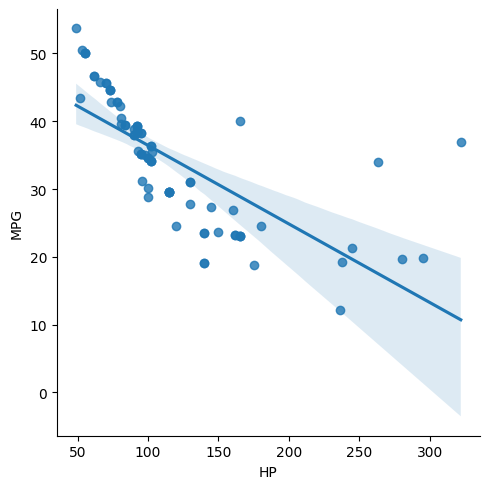

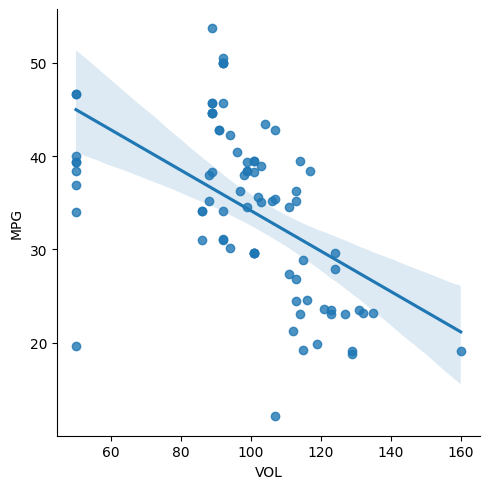

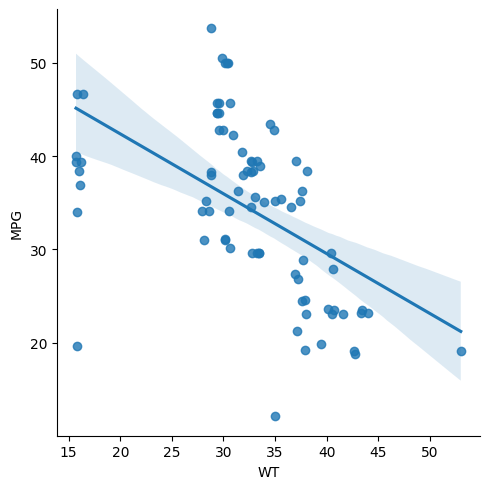

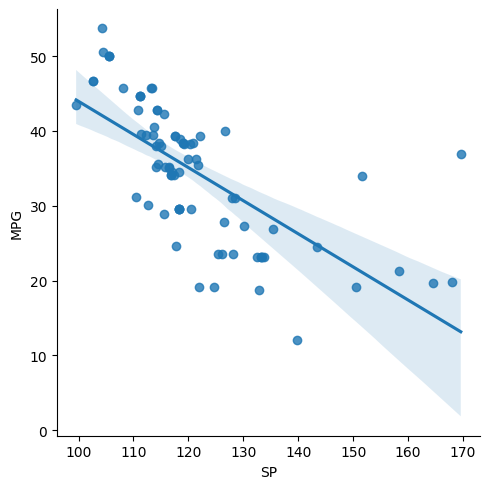

In [ ]:
sns.lmplot(data=cars_data,x="HP",y="MPG")
sns.lmplot(data=cars_data,x="VOL",y="MPG")
sns.lmplot(data=cars_data,x="WT",y="MPG")
sns.lmplot(data=cars_data,x="SP",y="MPG")
plt.show()

###Test 1 Fails

### Test 2: Normality Test

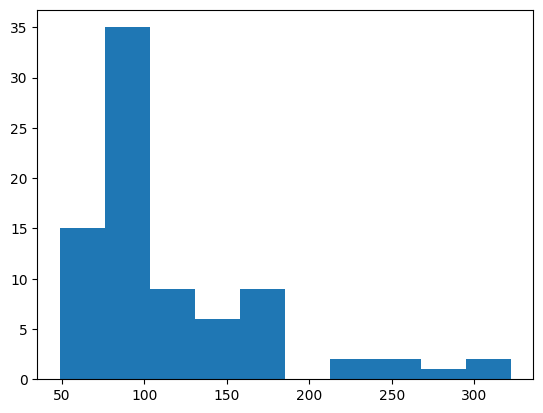

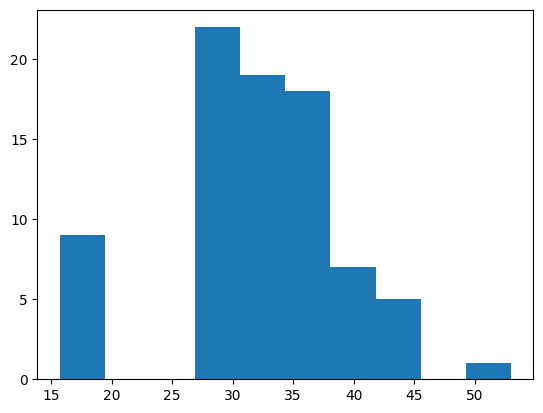

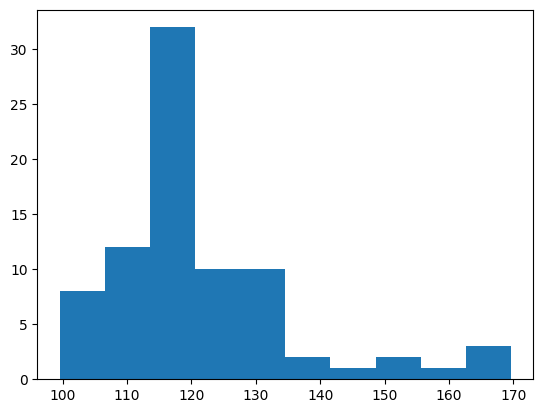

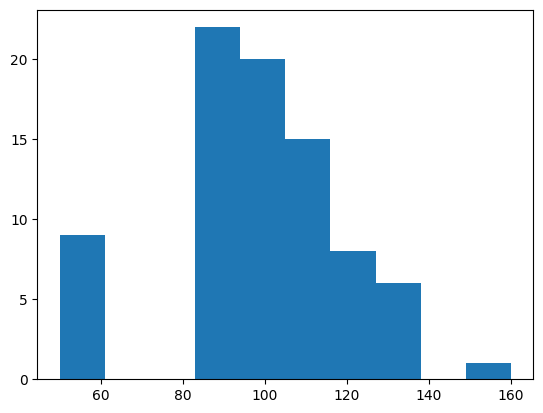

In [ ]:
plt.hist(x=cars_data['HP'])
plt.show()
plt.hist(x=cars_data["WT"])
plt.show()
plt.hist(x=cars_data["SP"])
plt.show()
plt.hist(x=cars_data["VOL"])
plt.show()

###Test 2 Normality test failed


###Test 3: Multi Collinearity Test

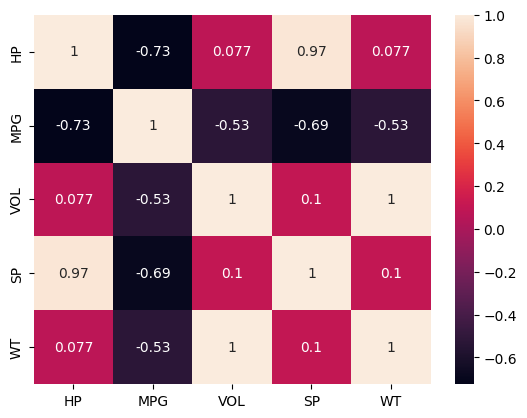

In [ ]:
corr_matrix = cars_data.corr()


sns.heatmap(data=corr_matrix,annot=True)
plt.show()

### Test 3 Multi Collinearity Test Failed

### Since, there is no time based parameters across the dataset, Test 4: AutoRegression Test Passed

## Step 4: Data Preparation

In [ ]:
cars_data
# Split the Input and Output parameters
X = cars_data[['HP','SP','VOL','WT']]
y = cars_data['MPG']
y

,MPG
0,53.700681
1,50.013401
2,50.013401
3,45.696322
4,50.504232
...,...
76,36.900000
77,19.197888
78,34.000000
79,19.833733


In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=True,
    random_state=36
)

###Since all the columns are numeric,no need of data preparation.Only the separation of input and output features was done in this step.


## Step 5: Model Building


In [ ]:
linear_model = LinearRegression()

##Step 6: Model Training

In [ ]:
linear_model.fit(X_train,y_train)

LinearRegression()

In [ ]:

linear_model.intercept_
linear_model.coef_

array([-0.1817796 ,  0.3027016 , -0.45396405,  0.76629041])

##Step 7: Model Testing

### Train Data Prediction

In [ ]:
y_pred_train = linear_model.predict(X_train)

In [ ]:
y_pred =linear_model.predict(X)
y_pred

array([43.44193477, 42.38879289, 42.27934147, 42.53835981, 42.17264802,
       43.02061916, 42.32536062, 48.07621852, 48.28120247, 40.79122814,
       41.52153227, 47.80956747, 39.95980269, 41.52757889, 41.76632332,
       41.6181448 , 41.15094046, 47.98605515, 41.30861046, 37.87127922,
       38.57706414, 37.35199705, 37.89770285, 39.5625144 , 39.93380662,
       46.73870908, 35.48165898, 38.78152504, 38.24861192, 36.00285298,
       34.84603989, 37.21630246, 37.13919796, 34.82541399, 37.22361389,
       37.53950097, 39.27144845, 38.24219888, 38.54286458, 35.9391722 ,
       34.2129755 , 35.36313259, 37.50473376, 38.07998482, 35.79651664,
       36.2613377 , 34.21826465, 35.59393404, 36.91805291, 33.31108154,
       33.21313413, 33.3023649 , 29.19864884, 27.52358579, 28.3207133 ,
       28.56722621, 35.81583602, 33.02108459, 35.37334971, 32.29909503,
       29.87685849, 28.76093817, 25.14188416, 26.47040896, 25.97651933,
       36.35652478, 26.0975912 , 23.6416178 , 24.39887199, 20.21

###Test Data Prediction

In [ ]:
y_pred_test = linear_model.predict(X_test)

## Step 8: Model Evaluation

In [ ]:
error = y - y_pred
error

,MPG
0,10.258747
1,7.624608
2,7.734060
3,3.157963
4,8.331584
...,...
76,15.617904
77,1.298838
78,7.863547
79,7.517122


###Training Data Evaluation


####Mean Absolute Error

In [ ]:
mean_absolute_error(y_train,y_pred_train)

3.522547667530438

####Mean Squared Error

In [ ]:
mean_squared_error(y_train,y_pred_train)

21.066092757616715

####Root Mean Squared error

In [ ]:
root_mean_squared_error(y_train,y_pred_train)

4.589781340937356

####r2 Score

In [ ]:
r2_score(y_train,y_pred_train)

0.7386624011006298

####Adjusted r2 score

In [ ]:
import statsmodels.api as sm

In [ ]:
X_train_sm = sm.add_constant(X_train["HP"])

In [ ]:
ols_train_model = sm.OLS(
    y_train,
    X_train_sm
).fit()

In [ ]:
print("r2 score:",ols_train_model.rsquared.round(4),"\nAdjusted r2 score:",ols_train_model.rsquared_adj.round(4))

r2 score: 0.7387 
Adjusted r2 score: 0.7209


In [ ]:
X_train_sm = sm.add_constant(X_train[["HP","VOL"]])

In [ ]:
ols_train_model = sm.OLS(
    y_train,
    X_train_sm
).fit()

In [ ]:
print("r2 score:",ols_train_model.rsquared.round(4),"\nAdjusted r2 score:",ols_train_model.rsquared_adj.round(4))

r2 score: 0.7258 
Adjusted r2 score: 0.7168


In [ ]:
X_train_sm = sm.add_constant(X_train[["HP","VOL","SP"]])


In [ ]:
ols_train_model = sm.OLS(
    y_train,
    X_train_sm
).fit()

In [ ]:
print("r2 score:",ols_train_model.rsquared.round(4),"\nAdjusted r2 score:",ols_train_model.rsquared_adj.round(4))

r2 score: 0.738 
Adjusted r2 score: 0.7249


In [ ]:
X_train_sm = sm.add_constant(X_train)


In [ ]:
ols_train_model = sm.OLS(
    y_train,
    X_train_sm
).fit()

In [ ]:
print("r2 score:",ols_train_model.rsquared.round(4),"\nAdjusted r2 score:",ols_train_model.rsquared_adj.round(4))

r2 score: 0.7387 
Adjusted r2 score: 0.7209


### Testing Data prediction Evaluation

#### Mean Absolute Error

In [ ]:
mean_absolute_error(
    y_test,
    y_pred_test
)

2.7261050260353676

####Mean Squared Error

In [ ]:
mean_squared_error(
    y_test,
    y_pred_test
)

11.703244588386918

####Root Mean Squared Error

In [ ]:
root_mean_squared_error(
    y_test,
    y_pred_test
)

3.421000524464578

####r2 score

In [ ]:
r2_score(
    y_test,
    y_pred_test
)

0.8493576855789342

#### Adjusted r2 score

In [ ]:
X_test_sm = sm.add_constant(X_test)

In [ ]:
linear_test_model = sm.OLS(
    y_test,
    X_test_sm
).fit()

In [ ]:
print("r2 score:",linear_test_model.rsquared.round(4),"\nAdjusted r2 score:",linear_test_model.rsquared_adj.round(4))

r2 score: 0.9033 
Adjusted r2 score: 0.8711


In [ ]:
y_pred_test = linear_test_model.predict(X_test)
r2_score(
    y_test,
    y_pred_test
)

0.9031021537241971

### Now will perform the other 2 assumption test in this model evaluation test

### Test 5: Homoscadesticity test

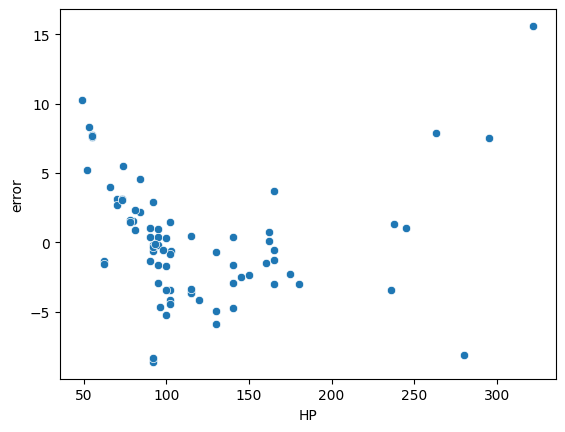

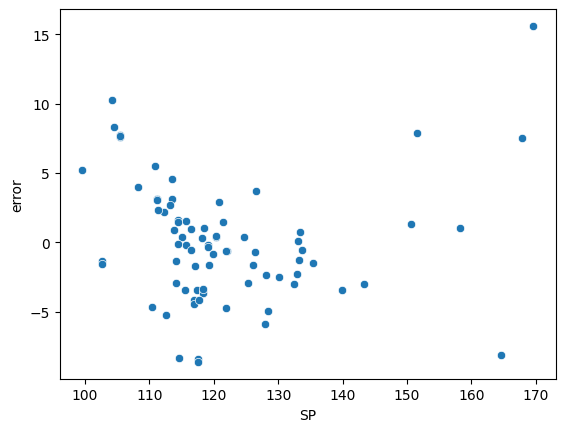

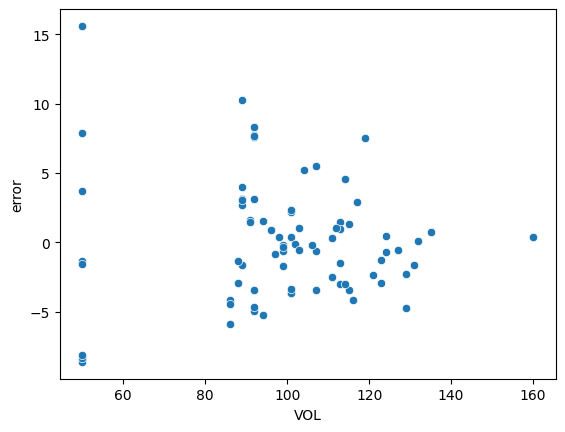

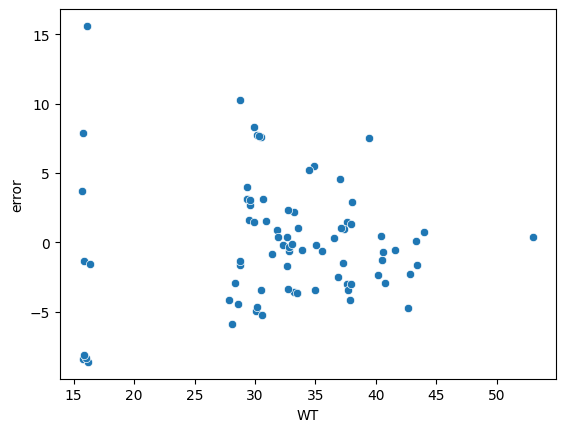

In [ ]:
sns.scatterplot(data=cars_data,x='HP',y=error)
plt.ylabel("error")
plt.show()
sns.scatterplot(data=cars_data,x="SP",y=error)
plt.ylabel("error")
plt.show()
sns.scatterplot(data=cars_data,x="VOL",y=error)
plt.ylabel("error")
plt.show()
sns.scatterplot(data=cars_data,x="WT",y=error)
plt.ylabel("error")
plt.show()

### Test 5 Homoscadesticity Test Failed

###Test 6: Zero Residual mean


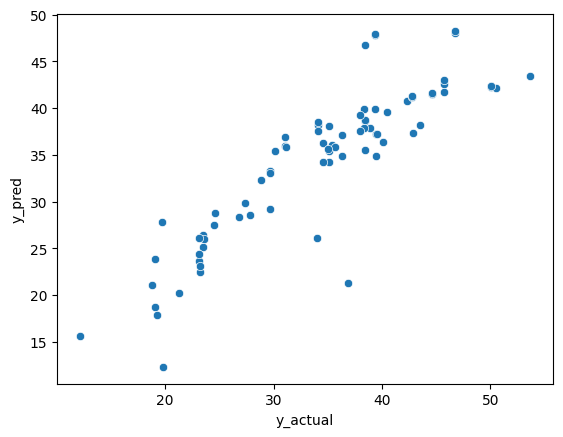

In [ ]:
sns.scatterplot(data=cars_data,x=cars_data["MPG"],y=y_pred)
plt.xlabel("y_actual")
plt.ylabel("y_pred")
plt.show()

### Test 6: Zero Residual mean test failed

## Step 9: Model Deployment

In [ ]:
from pickle import dump,load

dump(obj=linear_model,file=open("linear intelligence_file.pkl",mode="wb"))

linear_intel_pkl = load(file=open("linear intelligence_file.pkl",mode='rb'))

linear_intel_pkl.predict(X)


array([43.44193477, 42.38879289, 42.27934147, 42.53835981, 42.17264802,
       43.02061916, 42.32536062, 48.07621852, 48.28120247, 40.79122814,
       41.52153227, 47.80956747, 39.95980269, 41.52757889, 41.76632332,
       41.6181448 , 41.15094046, 47.98605515, 41.30861046, 37.87127922,
       38.57706414, 37.35199705, 37.89770285, 39.5625144 , 39.93380662,
       46.73870908, 35.48165898, 38.78152504, 38.24861192, 36.00285298,
       34.84603989, 37.21630246, 37.13919796, 34.82541399, 37.22361389,
       37.53950097, 39.27144845, 38.24219888, 38.54286458, 35.9391722 ,
       34.2129755 , 35.36313259, 37.50473376, 38.07998482, 35.79651664,
       36.2613377 , 34.21826465, 35.59393404, 36.91805291, 33.31108154,
       33.21313413, 33.3023649 , 29.19864884, 27.52358579, 28.3207133 ,
       28.56722621, 35.81583602, 33.02108459, 35.37334971, 32.29909503,
       29.87685849, 28.76093817, 25.14188416, 26.47040896, 25.97651933,
       36.35652478, 26.0975912 , 23.6416178 , 24.39887199, 20.21

## THE END..